# KNEEP_2D on Thermodynamically Consistent Lattice ABP (occupancy + angle)

This notebook trains the repository's direct 2D KNEEP implementation,
`models.NEEP_K_2DF.MultiScaleK_2DF`, on the MIPS state point used by
`data/lattice_abp_tc/mips_demo.ipynb`.  The physical parameters are copied
unchanged: $L=16$, $G=32$, $\sigma=0.5$, $\phi=0.30$, $v_0=50$,
$D_r=1.5$, $D_t=1$, and $dt=10^{-4}$.

The model is trained **without EP labels**.  The simulator separately records
the accepted-hop medium entropy production

$$
\Delta S_{\rm med}=\frac{\mathbf v\cdot\Delta\mathbf r-\mu\Delta V}{D_t}
$$

at each departure lattice site.  Those exact pathwise increments are used only
after model selection, for held-out total and local comparisons.

Important interpretation: the default observation is occupancy only.  It hides
particle orientation and all microscopic hops between two saved frames.  Data
processing bounds the **ensemble-mean observed path KL** by the microscopic
path KL; at steady state the mean system-entropy rate vanishes, allowing a
mean-rate comparison with microscopic medium EP.  A finite-capacity two-frame
KNEEP estimate, individual pairs, cumulative finite segments, and local pixels
do not automatically obey that bound.  They are shown here as diagnostics, not
as equal labels.  Set `OBSERVATION_MODE="occupancy_polarization"` to add
$\rho\cos\theta$ and $\rho\sin\theta$ channels.  In the angle notebook those
channels condition the learned force, while its final medium-EP contraction is
kept on $\Delta\rho$ only; `save_interval=100` still marginalizes the
intermediate path.

## 0. Environment

Run this notebook in the same CUDA-enabled environment as `mips_demo.ipynb`.
Install the packages in `data/lattice_abp_tc/requirements-l40s.txt`, install a
CUDA PyTorch wheel separately, and make sure `nvcc`, a host C++ compiler, and
Ninja are available.

Every accepted transition in this thermodynamically consistent dynamics must
have a finite log rate ratio.  The Torch, Numba, and fused CUDA samplers use
half-open inverse-CDF bins (`draw < cumulative`), so a zero-probability
direction cannot be selected even when the uniform draw is exactly zero.
Non-finite exact EP is therefore a fatal implementation or stale-cache error.
**Restart an already-running Jupyter kernel after updating the repository**,
because a previously loaded CUDA extension remains cached in that process.

In [46]:
from pathlib import Path
import hashlib
import importlib.util
import json
import math
import os
import platform
import re
import shutil
import subprocess
import sys
import time
import warnings
from argparse import Namespace
from datetime import datetime


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "lattice_abp_tc" / "core.py").exists():
            return path
    raise RuntimeError(
        "Could not find CNEEP_v2. Start Jupyter inside the repository or set the working directory."
    )


ROOT = find_repo_root("/home/ldh041203/projects/CNEEP_v2")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Set extension build variables before importing torch.
bootstrap_nvcc = shutil.which("nvcc.exe" if os.name == "nt" else "nvcc")
if bootstrap_nvcc and "CUDA_HOME" not in os.environ:
    os.environ["CUDA_HOME"] = str(Path(bootstrap_nvcc).resolve().parents[1])
os.environ.setdefault("TORCH_CUDA_ARCH_LIST", "8.9")
os.environ.setdefault("MAX_JOBS", str(min(8, os.cpu_count() or 1)))

required = ("numpy", "matplotlib", "tqdm", "ninja", "setuptools", "torch")
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(
        "Missing notebook packages: " + ", ".join(missing)
        + ". Install data/lattice_abp_tc/requirements-l40s.txt and CUDA PyTorch."
    )

print("repo:", ROOT)
print("python:", sys.executable)

repo: /home/ldh041203/projects/CNEEP_v2
python: /home/ldh041203/.conda/envs/jupyter-gpu/bin/python


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from torch.utils.cpp_extension import CUDA_HOME, is_ninja_available
from tqdm.auto import tqdm


if not torch.cuda.is_available():
    raise RuntimeError(
        f"CUDA is unavailable (torch={torch.__version__}, wheel CUDA={torch.version.cuda}). "
        "Select the CUDA-enabled Jupyter kernel."
    )

DEVICE = torch.device("cuda:0")
gpu = torch.cuda.get_device_properties(DEVICE)
capability = torch.cuda.get_device_capability(DEVICE)
if capability != (8, 9):
    warnings.warn(
        f"The reference target is an L40S (sm_89); found {gpu.name} "
        f"with sm_{capability[0]}{capability[1]}."
    )

nvcc_name = "nvcc.exe" if os.name == "nt" else "nvcc"
nvcc = None
if CUDA_HOME is not None:
    candidate = Path(CUDA_HOME) / "bin" / nvcc_name
    if candidate.is_file():
        nvcc = str(candidate)
if nvcc is None:
    nvcc = shutil.which(nvcc_name)
host_compiler = (
    shutil.which("cl.exe")
    if os.name == "nt"
    else (shutil.which("c++") or shutil.which("g++") or shutil.which("clang++"))
)

toolchain_errors = []
if torch.version.cuda is None:
    toolchain_errors.append("Installed PyTorch is CPU-only.")
if CUDA_HOME is None:
    toolchain_errors.append("CUDA_HOME was not detected by torch.utils.cpp_extension.")
if nvcc is None:
    toolchain_errors.append("nvcc was not found; install the CUDA Toolkit.")
if host_compiler is None:
    toolchain_errors.append("No compatible host C++ compiler was found on PATH.")
if not is_ninja_available():
    toolchain_errors.append("Ninja is unavailable.")
if toolchain_errors:
    raise RuntimeError("Fused CUDA prerequisites failed:\n- " + "\n- ".join(toolchain_errors))

from data.lattice_abp_tc._cuda_backend import (
    cuda_backend_buildable,
    load_cuda_backend,
)

if not cuda_backend_buildable():
    raise RuntimeError("The fused CUDA backend is not buildable in this kernel.")
cuda_extension = load_cuda_backend(verbose=True)

from data.lattice_abp_tc import ThermodynamicLatticeABP, ThermodynamicLatticeABPParams
from models.NEEP_K_2D import MultiScaleK_2D
from models.NEEP_ShellForce_2D import MultiScaleShellForceCNEEP2D
from models.NEEP_K_2DF import (
    MultiScaleK_2DF,
    kneep_normalize_branch_maps,
    kneep_spatial_mean_score,
    kneep_total_from_spatial_mean,
)

print(f"GPU: {gpu.name} ({gpu.total_memory / 2**30:.1f} GiB)")
print(f"PyTorch: {torch.__version__}, wheel CUDA: {torch.version.cuda}")
print(f"CUDA extension: {cuda_extension.__name__}")
print(f"platform: {platform.platform()}")

GPU: NVIDIA L40S (44.5 GiB)
PyTorch: 2.6.0+cu124, wheel CUDA: 12.4
CUDA extension: lattice_abp_cuda_5fef8ea6bdae
platform: Linux-5.15.0-94-generic-x86_64-with-glibc2.27


## 1. MIPS state point and KNEEP configuration

In [60]:
def n_from_packing_fraction(phi, box_size, sigma):
    return int(round(phi * 4.0 * box_size * box_size / (math.pi * sigma * sigma)))


# --------------------------- user switches ---------------------------
REUSE_TRAJECTORY = True
ANGLE_OBSERVATION = True
OBSERVATION_MODE = "occupancy_polarization" if ANGLE_OBSERVATION else "occupancy"

# ---------------- MIPS demo physical parameters: unchanged ----------------
L = 15.0
GRID_SIZE = 30
SIGMA = 0.5
PHI = 0.30
N = n_from_packing_fraction(PHI, L, SIGMA)

physics = dict(
    N=N,
    L=L,
    grid_size=GRID_SIZE,
    sigma=SIGMA,
    epsilon=1.0,
    mobility=1.0,
    v0=50.0,
    Dr=1.5,
    Dt=1.0,
    dt=1.0e-4,
    prefactor="cv",
    strict_probabilities=True,
    probability_tolerance=1.0e-6,
    shuffle_particles=True,
    seed=7,
    device=str(DEVICE),
    dtype="float32",
    update_scheme="five_color",
    backend="torch",
)

# Train/validation and test are simulated independently so the held-out
# trajectory can be much longer without changing the training data budget.
B_TRAIN_VAL = 100
B_TEST = 1
N_TRAIN_ENSEMBLES = 80
N_VALIDATION_ENSEMBLES = 20
N_TEST_ENSEMBLES = 1
burn_in = 100_000
train_val_n_steps = 50_000
test_n_steps = 200_000
save_interval = 5

if OBSERVATION_MODE not in {"occupancy", "occupancy_polarization"}:
    raise ValueError(f"Unknown OBSERVATION_MODE={OBSERVATION_MODE!r}")
if B_TRAIN_VAL != N_TRAIN_ENSEMBLES + N_VALIDATION_ENSEMBLES:
    raise ValueError("B_TRAIN_VAL must equal train + validation ensemble counts.")
if B_TEST != N_TEST_ENSEMBLES:
    raise ValueError("B_TEST must equal N_TEST_ENSEMBLES.")
if N_TEST_ENSEMBLES != 1:
    raise ValueError("This notebook expects exactly one held-out test trajectory.")
if any(n <= 0 or n % save_interval != 0 for n in (train_val_n_steps, test_n_steps)):
    raise ValueError("Each trajectory length must be positive and divisible by save_interval.")
if min(train_val_n_steps, test_n_steps) // save_interval < 4:
    raise ValueError("Save at least four trajectory intervals.")

opt = Namespace()
# Select MultiScaleK_2DF, MultiScaleK_2D, or plain MultiScaleShellForceCNEEP2D.
opt.model_type = "MultiScaleK_2DF"
opt.device = str(DEVICE)
opt.alpha = -0.5
opt.beta = 1.0
opt.positional = False
opt.seq_len = 2
opt.max_distance = 3
opt.include_k0 = True
# ShellForce settings (used only when model_type is MultiScaleShellForceCNEEP2D).
opt.shell_center_mode = "relative_only"
opt.shell_force_bias = True
opt.shell_relative_mode = "learned_absolute"
opt.shell_weight_normalization = "none"
opt.shell_force_activation = "elu"
opt.n_channel = 32
opt.n_hidden = 3
opt.n_components = 1 if OBSERVATION_MODE == "occupancy" else 3
opt.input_shape = (GRID_SIZE, GRID_SIZE)
# Match the effective settings in the existing Corr_LatticeABP_TC notebook.
opt.k_kernel_geometry = "euclidean"
# if ANGLE_OBSERVATION:
#     # Polarization channels condition the learned force, but medium EP is
#     # contracted only with the occupancy displacement, not with Δtheta-like
#     # polarization changes.
#     opt.ep_component_indices = (0,)
opt.n_iter = 10_000
opt.train_batch_size = 2048
opt.eval_batch_size = 256
opt.lr = 1.0e-4
opt.wd = 1.0e-2
opt.clip_norm = 1.0
opt.record_freq = 100
opt.seed = 3

torch.manual_seed(opt.seed)
np.random.seed(opt.seed)

dt_saved = save_interval * physics["dt"]
params = ThermodynamicLatticeABPParams(**physics)
sim = ThermodynamicLatticeABP(params)

RESULT_ROOT = ROOT / "results"
run_tag = datetime.now().strftime("%Y-%m-%d-%H%M%S")
run_label = "CorrLABP-TC-KNEEP2D-angle" if ANGLE_OBSERVATION else "CorrLABP-TC-KNEEP2D"
current_result_folder = RESULT_ROOT / f"{run_label}-{run_tag}"
current_result_folder.mkdir(parents=True, exist_ok=False)
best_checkpoint_path = current_result_folder / "best_model_parameter.pth.tar"
current_checkpoint_path = current_result_folder / "model_parameter.pth.tar"

SAMPLER_SOURCE_FILES = (
    "data/lattice_abp_tc/core.py",
    "data/lattice_abp_tc/_numba_backend.py",
    "data/lattice_abp_tc/_cuda_backend.py",
    "data/lattice_abp_tc/csrc/cuda_sweep.cpp",
    "data/lattice_abp_tc/csrc/cuda_sweep_kernel.cu",
)
sampler_source_sha256 = hashlib.sha256(
    b"".join((ROOT / path).read_bytes() for path in SAMPLER_SOURCE_FILES)
).hexdigest()
trajectory_config_base = {
    "cache_version": 2,  # Exact local-EP dataset schema/source version.
    "sampler_source_sha256": sampler_source_sha256,
    "physics": {k: v for k, v in physics.items() if k != "device"},
    "burn_in": burn_in,
    "save_interval": save_interval,
}
trajectory_config_train_val = {
    **trajectory_config_base, "split": "train_val", "B": B_TRAIN_VAL, "n_steps": train_val_n_steps,
}
trajectory_config_test = {
    **trajectory_config_base, "split": "test", "B": B_TEST, "n_steps": test_n_steps,
    # Use an independent test realization rather than one member of the
    # train/validation simulation batch.
    "physics": {**trajectory_config_base["physics"], "seed": physics["seed"] + 1},
}
trajectory_config = {
    "train_validation": trajectory_config_train_val,
    "test": trajectory_config_test,
}
train_val_cache_id = hashlib.sha256(
    json.dumps(trajectory_config_train_val, sort_keys=True).encode("utf-8")
).hexdigest()[:16]
test_cache_id = hashlib.sha256(
    json.dumps(trajectory_config_test, sort_keys=True).encode("utf-8")
).hexdigest()[:16]
CACHE_DIR = ROOT / "output" / "lattice_abp_tc_kneep"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
train_val_trajectory_cache = CACHE_DIR / f"trajectory_{train_val_cache_id}.pt"
test_trajectory_cache = CACHE_DIR / f"trajectory_{test_cache_id}.pt"

print(
    f"L={params.L:g}, G={params.grid_size}, dl={params.dl:g}, N={params.N}, "
    f"phi={params.phi:.6f}, Pe={params.Pe:.3f}, gamma2={params.gamma2:.1f}"
)
print(
    f"train/val: B={B_TRAIN_VAL}, n_steps={train_val_n_steps}; "
    f"test: B={B_TEST}, n_steps={test_n_steps}; burn_in={burn_in}, "
    f"save_interval={save_interval}, dt_saved={dt_saved:g}"
)
print(f"observation={OBSERVATION_MODE}, KNEEP components={opt.n_components}")
print("train/val trajectory cache:", train_val_trajectory_cache)
print("test trajectory cache:", test_trajectory_cache)
print("results:", current_result_folder)

L=15, G=30, dl=0.5, N=344, phi=0.300197, Pe=66.667, gamma2=2500.0
train/val: B=100, n_steps=50000; test: B=1, n_steps=200000; burn_in=100000, save_interval=5, dt_saved=0.0005
observation=occupancy_polarization, KNEEP components=3
train/val trajectory cache: /home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_kneep/trajectory_465e0142c3777e8c.pt
test trajectory cache: /home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_kneep/trajectory_b2444f3ad73c39aa.pt
results: /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-TC-KNEEP2D-angle-2026-08-24-205656


## 2. Equilibrated trajectory with exact local medium EP

In [49]:
# Recreate simulators immediately before the production runs so cache
# provenance explicitly corresponds to the recorded seeds.
sim_train_val = ThermodynamicLatticeABP(params)
test_physics = {**physics, "seed": physics["seed"] + 1}
test_params = ThermodynamicLatticeABPParams(**test_physics)
sim_test = ThermodynamicLatticeABP(test_params)

tensor_keys = (
    "sites",
    "theta",
    "times",
    "occupancy",
    "accepted_hops",
    "exact_medium_ep",
    "exact_active_medium_ep",
    "exact_wca_medium_ep",
    "exact_medium_ep_rate",
    "exact_medium_ep_maps",
)

def load_or_simulate(simulator, B_here, n_steps_here, cache_path, label):
    if REUSE_TRAJECTORY and cache_path.exists():
        try:
            saved = torch.load(cache_path, map_location="cpu", weights_only=True)
        except TypeError:  # PyTorch < 2.0
            saved = torch.load(cache_path, map_location="cpu")
        missing_keys = sorted(set(tensor_keys) - set(saved))
        if missing_keys:
            raise RuntimeError(f"Stale {label} cache is missing {missing_keys}: {cache_path}")
        print(f"loaded {label}:", cache_path)
        return saved

    torch.cuda.synchronize(DEVICE)
    started = time.perf_counter()
    raw = simulator.simulate(
        B=B_here, burn_in=burn_in, n_steps=n_steps_here,
        save_interval=save_interval, show_progress=True, save_diagnostics=False,
        save_occupancy=True, save_exact_medium_ep=True, save_ep_maps=True,
    )
    torch.cuda.synchronize(DEVICE)
    saved = {key: raw[key] for key in tensor_keys}
    elapsed = time.perf_counter() - started
    print(f"simulated {label} in {elapsed:.2f} s "
          f"({B_here * (burn_in + n_steps_here) / max(elapsed, 1e-12):.1f} ensemble sweeps/s)")
    temporary_cache = cache_path.with_suffix(cache_path.suffix + ".tmp")
    torch.save(saved, temporary_cache)
    os.replace(temporary_cache, cache_path)
    del raw
    torch.cuda.empty_cache()
    return saved


def validate_exact_result(saved, expected_B, simulator, label):
    if not bool(torch.isfinite(saved["exact_medium_ep"]).all()):
        raise RuntimeError(f"Non-finite exact EP in {label} result.")
    if not bool(torch.isfinite(saved["exact_medium_ep_maps"]).all()):
        raise RuntimeError(f"Non-finite exact local EP map in {label} result.")
    assert saved["occupancy"].shape[1] == expected_B
    assert int(saved["occupancy"].min()) >= 0 and int(saved["occupancy"].max()) <= 1
    assert bool((saved["occupancy"].sum(dim=(-2, -1)) == simulator.N).all())
    torch.testing.assert_close(saved["exact_medium_ep_maps"].sum(dim=(-2, -1)).T, saved["exact_medium_ep"], rtol=2e-5, atol=2e-4)
    torch.testing.assert_close(saved["exact_active_medium_ep"] + saved["exact_wca_medium_ep"], saved["exact_medium_ep"], rtol=2e-5, atol=2e-4)


train_val_result = load_or_simulate(sim_train_val, B_TRAIN_VAL, train_val_n_steps, train_val_trajectory_cache, "train/validation")
test_result = load_or_simulate(sim_test, B_TEST, test_n_steps, test_trajectory_cache, "test")
validate_exact_result(train_val_result, B_TRAIN_VAL, sim_train_val, "train/validation")
validate_exact_result(test_result, B_TEST, sim_test, "test")

def stationarity_diagnostics(saved):
    rates = saved["exact_medium_ep_rate"].numpy()
    half = max(1, rates.shape[1] // 2)
    early, late, overall = rates[:, :half].mean(axis=1), rates[:, half:].mean(axis=1), rates.mean(axis=1)
    return {
        "early_exact_medium_ep_rate": early.tolist(),
        "late_exact_medium_ep_rate": late.tolist(),
        "relative_exact_ep_drift": (np.abs(late - early) / np.maximum(np.abs(overall), 1e-12)).tolist(),
    }


stationarity = {"train_validation": stationarity_diagnostics(train_val_result), "test": stationarity_diagnostics(test_result)}
print("train/validation occupancy:", tuple(train_val_result["occupancy"].shape))
print("test occupancy:", tuple(test_result["occupancy"].shape))
print("test exact total EP:", tuple(test_result["exact_medium_ep"].shape))
print(
    "test mean exact medium EP per saved transition:",
    test_result["exact_medium_ep"].mean(dim=1).numpy(),
)

simulated train/validation in 889.65 s (16860.6 ensemble sweeps/s)
loaded test: /home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_kneep/trajectory_b2444f3ad73c39aa.pt
train/validation occupancy: (10001, 100, 30, 30)
test occupancy: (40001, 1, 30, 30)
test exact total EP: (1, 40000)
test mean exact medium EP per saved transition: [59.724113]


## 3. Observed fields and ensemble split

Arrays from the simulator are time-major.  KNEEP uses
`[ensemble, time, component, x, y]`.  The exact map is changed from
`[time_pair, ensemble, x, y]` to `[ensemble, time_pair, x, y]` with the same
pair index.

The 100 train/validation replicas are simulated together: replicas 0--79 are
used for training and 80--99 for validation.  The one held-out test replica is
simulated independently with a different seed and 10 times more saved
intervals.  Its exact EP never enters training or checkpoint selection.

In [50]:
def encode_observed_fields(simulation_result, mode):
    occupancy = simulation_result["occupancy"].float()  # [T,B,G,G]
    if mode == "occupancy":
        return occupancy.permute(1, 0, 2, 3).unsqueeze(2).contiguous()
    if mode != "occupancy_polarization":
        raise ValueError(f"Unknown OBSERVATION_MODE={mode!r}")

    sites = simulation_result["sites"].long()            # [T,B,N,2]
    theta = simulation_result["theta"].float()           # [T,B,N]
    T, B_here, _, _ = sites.shape
    linear = sites[..., 0] * GRID_SIZE + sites[..., 1]
    pol_x = torch.zeros((T, B_here, GRID_SIZE * GRID_SIZE), dtype=torch.float32)
    pol_y = torch.zeros_like(pol_x)
    pol_x.scatter_add_(2, linear, torch.cos(theta))
    pol_y.scatter_add_(2, linear, torch.sin(theta))
    pol_x = pol_x.view(T, B_here, GRID_SIZE, GRID_SIZE)
    pol_y = pol_y.view(T, B_here, GRID_SIZE, GRID_SIZE)
    fields = torch.stack((occupancy, pol_x, pol_y), dim=2)
    return fields.permute(1, 0, 2, 3, 4).contiguous()


observed_train_val = encode_observed_fields(train_val_result, OBSERVATION_MODE)
observed_test = encode_observed_fields(test_result, OBSERVATION_MODE)
# The cache already contains these raw tensors; remaining cells use encoded fields.
train_val_result.pop("sites")
train_val_result.pop("theta")
test_result.pop("sites")
test_result.pop("theta")
gt_local_train_val = train_val_result["exact_medium_ep_maps"].permute(1, 0, 2, 3).contiguous()
gt_total_train_val = train_val_result["exact_medium_ep"]
gt_local_test = test_result["exact_medium_ep_maps"].permute(1, 0, 2, 3).contiguous()
gt_total_test = test_result["exact_medium_ep"]

assert observed_train_val.shape[:2] == (B_TRAIN_VAL, train_val_n_steps // save_interval + 1)
assert observed_test.shape[:2] == (B_TEST, test_n_steps // save_interval + 1)
assert observed_train_val.shape[2:] == observed_test.shape[2:] == (opt.n_components, GRID_SIZE, GRID_SIZE)
assert gt_local_train_val.shape[:2] == (B_TRAIN_VAL, observed_train_val.shape[1] - 1)
assert gt_local_test.shape[:2] == (B_TEST, observed_test.shape[1] - 1)
torch.testing.assert_close(
    gt_local_train_val.sum(dim=(-2, -1)), gt_total_train_val, rtol=2.0e-5, atol=2.0e-4
)
torch.testing.assert_close(
    gt_local_test.sum(dim=(-2, -1)), gt_total_test, rtol=2.0e-5, atol=2.0e-4
)

train_ensemble_ids = torch.arange(0, N_TRAIN_ENSEMBLES)
val_ensemble_ids = torch.arange(
    N_TRAIN_ENSEMBLES,
    N_TRAIN_ENSEMBLES + N_VALIDATION_ENSEMBLES,
)
test_ensemble_ids = torch.tensor([0])
assert len(train_ensemble_ids) == 80
assert len(val_ensemble_ids) == 20
assert test_ensemble_ids.tolist() == [0]

# Contiguous slices stay as views and avoid duplicating the large field tensor.
train_video = observed_train_val[:N_TRAIN_ENSEMBLES]
val_video = observed_train_val[
    N_TRAIN_ENSEMBLES : N_TRAIN_ENSEMBLES + N_VALIDATION_ENSEMBLES
]
test_video = observed_test

channel_mean = train_video.mean(dim=(0, 1, 3, 4), keepdim=True)
channel_std = train_video.std(dim=(0, 1, 3, 4), keepdim=True).clamp_min(1.0e-6)


def normalize_pairs(x):
    return (x - channel_mean) / channel_std


print("train/validation observed:", tuple(observed_train_val.shape))
print("test observed:", tuple(observed_test.shape))
print("train/val/test replicas:", train_ensemble_ids.tolist(), val_ensemble_ids.tolist(), test_ensemble_ids.tolist())
print("channel mean:", channel_mean.flatten().numpy())
print("channel std:", channel_std.flatten().numpy())

train/validation observed: (100, 10001, 3, 30, 30)
test observed: (1, 40001, 3, 30, 30)
train/val/test replicas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79] [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99] [0]
channel mean: [3.86776358e-01 7.39524898e-04 1.05028514e-04]
channel std: [0.48593044 0.43742937 0.43689498]


## 4. KNEEP_2D model and unsupervised objective

In [61]:
# Make model initialization and random pair batches independent of whether the
# trajectory was simulated or loaded from cache.
torch.manual_seed(opt.seed)
np.random.seed(opt.seed)
torch.cuda.manual_seed_all(opt.seed)
if opt.model_type == "MultiScaleK_2DF":
    model = MultiScaleK_2DF(opt).to(opt.device)
elif opt.model_type == "MultiScaleK_2D":
    model = MultiScaleK_2D(opt).to(opt.device)
elif opt.model_type == "MultiScaleShellForceCNEEP2D":
    model = MultiScaleShellForceCNEEP2D(opt).to(opt.device)
else:
    raise ValueError(f"Unknown model type: {opt.model_type!r}")
optimizer = torch.optim.AdamW(model.parameters(), lr=opt.lr, weight_decay=opt.wd)
print(f"model parameters: {sum(p.numel() for p in model.parameters()):,}")


def make_pair_batch(video, ensemble_idx, time_idx):
    x0 = video[ensemble_idx, time_idx]
    x1 = video[ensemble_idx, time_idx + 1]
    x = torch.stack((x0, x1), dim=1)
    x = normalize_pairs(x)
    if opt.n_components == 1:
        x = x.squeeze(2)  # MultiScaleK_2DF expects [batch,time,x,y] for one component.
    return x.to(opt.device, non_blocking=True)


def random_pair_batch(video, batch_size):
    ensemble_idx = torch.randint(video.shape[0], (batch_size,))
    time_idx = torch.randint(video.shape[1] - 1, (batch_size,))
    return make_pair_batch(video, ensemble_idx, time_idx)


def ordered_pair_batches(video, batch_size):
    n_pairs = video.shape[1] - 1
    flat = torch.arange(video.shape[0] * n_pairs)
    for start in range(0, len(flat), batch_size):
        ids = flat[start : start + batch_size]
        yield ids // n_pairs, ids % n_pairs


def alpha_neep_loss(score, alpha):
    if alpha == 0:
        return (-score + torch.exp(-score) - 1.0).mean()
    return (
        -(torch.exp(alpha * score) - 1.0) / alpha
        + (torch.exp(-(1.0 + alpha) * score) - 1.0) / (1.0 + alpha)
    ).mean()


def spatial_mean_score(x):
    """Stable intensive score, matching utils.train/utils.validate."""
    return model(x).sum(dim=1)


@torch.no_grad()
def evaluate_objective(video):
    model.eval()
    total = 0.0
    count = 0
    for ensemble_idx, time_idx in ordered_pair_batches(video, opt.eval_batch_size):
        x = make_pair_batch(video, ensemble_idx, time_idx)
        score = spatial_mean_score(x)
        batch_loss = alpha_neep_loss(score, opt.alpha)
        total += float(batch_loss) * len(x)
        count += len(x)
    return total / max(count, 1)


# Model API and antisymmetry invariant check before training.
model.eval()
with torch.no_grad():
    x_check = random_pair_batch(train_video, min(2, opt.train_batch_size))
    j_check = model(x_check)
    maps_check = model(x_check, return_maps=True)
    assert j_check.shape == (len(x_check), opt.max_distance + 1)
    assert maps_check.shape == (len(x_check), opt.max_distance + 1, GRID_SIZE, GRID_SIZE)
    torch.testing.assert_close(j_check, maps_check.mean(dim=(-2, -1)), rtol=2e-5, atol=2e-6)
    torch.testing.assert_close(
        model(torch.flip(x_check, dims=[1]), return_maps=True),
        -maps_check,
        rtol=2e-5,
        atol=2e-6,
    )
print("KNEEP shape/antisymmetry check passed")

model parameters: 38,924
KNEEP shape/antisymmetry check passed


KNEEP training:   0%|                                                                        | 0/10000 [00:00<?, ?it/s]

KNEEP training:   0%|                                                             | 2/10000 [00:09<11:13:15,  4.04s/it]

iter=    1 train=-3.697387e+00 val=-3.762030e+00 best=-3.762030e+00


KNEEP training:   1%|▌                                                           | 101/10000 [00:47<6:07:28,  2.23s/it]

iter=  100 train=-3.734397e+00 val=-3.762038e+00 best=-3.762038e+00


...

iter= 9800 train=-3.781166e+00 val=-3.761264e+00 best=-3.762514e+00


KNEEP training:  99%|██████████████████████████████████████████████████████████▍| 9900/10000 [1:03:19<05:16,  3.16s/it]

iter= 9900 train=-3.748276e+00 val=-3.761274e+00 best=-3.762514e+00


KNEEP training: 100%|██████████████████████████████████████████████████████████| 10000/10000 [1:03:57<00:00,  2.61it/s]

iter=10000 train=-3.748005e+00 val=-3.761260e+00 best=-3.762514e+00
loaded best checkpoint from iteration 3200


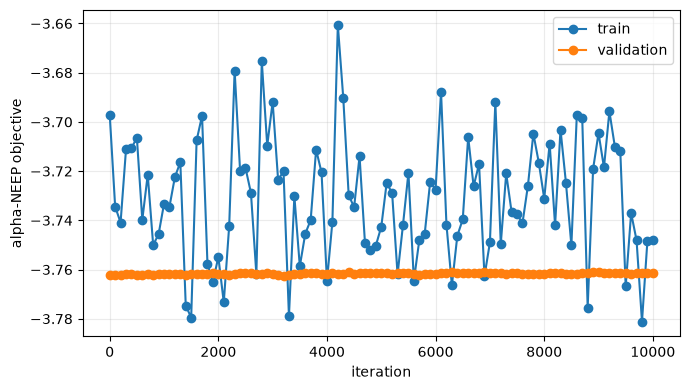

In [72]:
best_val_loss = float("inf")
history_iter = []
history_train = []
history_val = []

for iteration in tqdm(range(1, opt.n_iter + 1), desc="KNEEP training"):
    model.train()
    x = random_pair_batch(train_video, opt.train_batch_size)
    score = spatial_mean_score(x)
    loss = alpha_neep_loss(score, opt.alpha)
    # if not bool(torch.isfinite(loss)):
    #     raise FloatingPointError(f"non-finite training loss at iteration {iteration}")

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), opt.clip_norm)
    optimizer.step()

    if iteration == 1 or iteration % opt.record_freq == 0 or iteration == opt.n_iter:
        val_loss = evaluate_objective(val_video)
        if not math.isfinite(val_loss):
            raise FloatingPointError(f"non-finite validation loss at iteration {iteration}")
        history_iter.append(iteration)
        history_train.append(float(loss.detach().cpu()))
        history_val.append(val_loss)

        state = {
            "settings": vars(opt),
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "iteration": iteration,
            "train_loss": history_train[-1],
            "val_loss": val_loss,
            "channel_mean": channel_mean,
            "channel_std": channel_std,
            "physics": physics,
            "trajectory_config": trajectory_config,
            "observation_mode": OBSERVATION_MODE,
        }
        torch.save(state, current_checkpoint_path)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(state, best_checkpoint_path)

        print(
            f"iter={iteration:5d} train={history_train[-1]:+.6e} "
            f"val={val_loss:+.6e} best={best_val_loss:+.6e}"
        )

checkpoint = torch.load(best_checkpoint_path, map_location=opt.device, weights_only=False)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print(f"loaded best checkpoint from iteration {checkpoint['iteration']}")
if checkpoint["val_loss"] >= -1.0e-6:
    warnings.warn(
        "Best validation objective did not improve meaningfully over the zero-score baseline (0). "
        "Treat downstream EP plots as a failed-learning diagnostic."
    )

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_iter, history_train, "o-", label="train")
ax.plot(history_iter, history_val, "o-", label="validation")
ax.set_xlabel("iteration")
ax.set_ylabel("alpha-NEEP objective")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(current_result_folder / "training_loss.png", dpi=160)
plt.show()

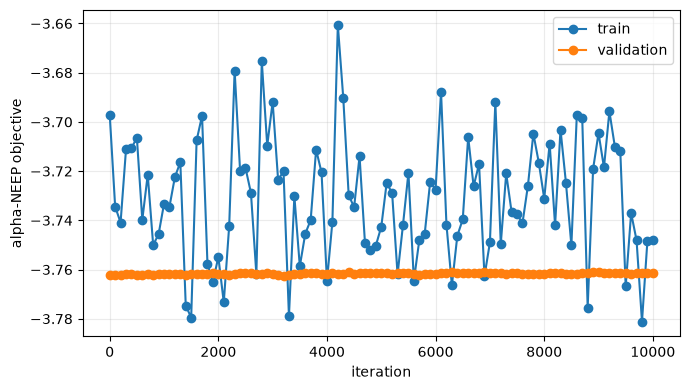

In [73]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_iter, history_train, "o-", label="train")
ax.plot(history_iter, history_val, "o-", label="validation")
ax.set_xlabel("iteration")
ax.set_ylabel("alpha-NEEP objective")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(current_result_folder / "training_loss.png", dpi=160)
plt.show()

## 5. Held-out prediction and exact-map alignment

`MultiScaleK_2DF` returns the spatial **mean** of each branch map.  This notebook
follows the spatial-mean training convention: the branchwise spatial mean is
used both inside the exponential NEEP objective and for total EP.  No extra
`G^2` multiplication or division is applied to that scalar:

```text
normalized map_k                 = raw map_k / G^2
predicted local increment at site = sum_k normalized map_k
predicted total increment         = sum_k spatial_mean(raw map_k)
                                  = sum_k J_k  (no extra /G^2)
```

The exact simulator map is already an increment per departure site, so no
$d\ell^2$ factor is inserted.  The saved-frame interval is already encoded in
both the learned and exact increments; neither prediction is divided by
`dt_saved` in the comparisons below.  A rate can be derived later as a
separately labelled post-processing quantity.

α-NEEP is trained on the spatial mean of each raw branch map.  Every predicted
map is divided by `G^2` before local interpretation.  Its site sum therefore
equals the spatial-mean model score, with no additional `G^2` factor.

In [74]:
@torch.no_grad()
def predict_raw_branch_maps(video):
    model.eval()
    chunks = []
    for ensemble_idx, time_idx in tqdm(
        ordered_pair_batches(video, opt.eval_batch_size),
        total=math.ceil(video.shape[0] * (video.shape[1] - 1) / opt.eval_batch_size),
        desc="held-out maps",
    ):
        x = make_pair_batch(video, ensemble_idx, time_idx)
        branch_maps = model(x, return_maps=True)
        chunks.append(branch_maps.detach().cpu())
    return torch.cat(chunks, dim=0)


raw_pred_branch_maps = predict_raw_branch_maps(test_video)  # [Npair,K,G,G]
expected_test_pairs = test_video.shape[0] * (test_video.shape[1] - 1)
assert raw_pred_branch_maps.shape == (
    expected_test_pairs,
    opt.max_distance + 1,
    GRID_SIZE,
    GRID_SIZE,
)
assert bool(torch.isfinite(raw_pred_branch_maps).all())
pred_branch_inc_maps = kneep_normalize_branch_maps(raw_pred_branch_maps)
pred_local_inc = pred_branch_inc_maps.sum(dim=1)
pred_total_inc = kneep_spatial_mean_score(raw_pred_branch_maps)

gt_local_inc = gt_local_test.reshape(-1, GRID_SIZE, GRID_SIZE)
gt_total_inc = gt_total_test.reshape(-1)
torch.testing.assert_close(
    gt_local_inc.sum(dim=(-2, -1)), gt_total_inc, rtol=2.0e-5, atol=2.0e-4
)
torch.testing.assert_close(
    kneep_total_from_spatial_mean(
        raw_pred_branch_maps.mean(dim=(-2, -1)),
        (GRID_SIZE, GRID_SIZE),
    ),
    pred_total_inc,
    rtol=2.0e-5,
    atol=2.0e-4,
)

pred_total_ep = pred_total_inc.numpy()
gt_total_ep = gt_total_inc.numpy()
pred_local_ep = pred_local_inc.numpy()
gt_local_ep = gt_local_inc.numpy()
assert np.isfinite(pred_total_ep).all()
assert np.isfinite(gt_total_ep).all()
assert np.isfinite(pred_local_ep).all()
assert np.isfinite(gt_local_ep).all()
if float(pred_total_ep.mean()) <= 0.0:
    warnings.warn("Held-out mean KNEEP score is non-positive; training did not resolve positive irreversibility.")

# Unit audit.  The simulator's map is microscopic hop-wise medium EP, whereas
# KNEEP estimates an observed two-frame score.  The latter is not a pointwise
# label.  The identities below follow the same mean-map/site-sum convention as
# the no-angle notebook and catch stale/manual plotting cells.
map_sum_check = pred_branch_inc_maps.sum(dim=(1, 2, 3))
score_from_model = torch.cat(
    [
        spatial_mean_score(
            make_pair_batch(
                test_video,
                ensemble_idx,
                time_idx,
            )
        ).detach().cpu()
        for ensemble_idx, time_idx in ordered_pair_batches(test_video, opt.eval_batch_size)
    ]
)
torch.testing.assert_close(map_sum_check, pred_total_inc, rtol=2.0e-5, atol=2.0e-4)
torch.testing.assert_close(
    score_from_model, pred_total_inc, rtol=2.0e-5, atol=2.0e-4
)
np.testing.assert_allclose(gt_local_ep.sum(axis=(-2, -1)), gt_total_ep, rtol=2.0e-5, atol=2.0e-4)
scale_audit = {
    "dt_saved": float(dt_saved),
    "grid_sites": int(GRID_SIZE**2),
    "raw_map_to_local_factor": float(1.0 / GRID_SIZE**2),
    "model_score_to_total_factor": 1,
    "mean_true_microscopic_total_increment": float(gt_total_inc.mean()),
    "mean_true_microscopic_site_increment": float(gt_local_ep.mean()),
    "mean_predicted_observed_total_increment": float(pred_total_inc.mean()),
    "mean_predicted_observed_site_increment": float(pred_local_ep.mean()),
    "observed_to_microscopic_total_increment_ratio": float(
        pred_total_ep.mean() / gt_total_ep.mean()
    ),
    "true_local_increment_min": float(gt_local_ep.min()),
    "true_local_increment_max": float(gt_local_ep.max()),
    "predicted_local_increment_min": float(pred_local_ep.min()),
    "predicted_local_increment_max": float(pred_local_ep.max()),
}
print("scale audit:")
print(json.dumps(scale_audit, indent=2))


def comparison_metrics(target, prediction):
    target = np.asarray(target, dtype=np.float64)
    prediction = np.asarray(prediction, dtype=np.float64)
    if target.shape != prediction.shape:
        raise ValueError(f"metric shape mismatch: {target.shape} != {prediction.shape}")
    if not (np.isfinite(target).all() and np.isfinite(prediction).all()):
        raise ValueError("comparison_metrics received non-finite values")
    residual = prediction - target
    denom = np.sum((target - target.mean()) ** 2)
    correlation = (
        float(np.corrcoef(target, prediction)[0, 1])
        if len(target) > 1 and target.std() > 0 and prediction.std() > 0
        else float("nan")
    )
    return {
        "count": int(len(target)),
        "target_mean": float(target.mean()),
        "prediction_mean": float(prediction.mean()),
        "mean_ratio": float(prediction.mean() / target.mean()) if target.mean() != 0 else float("nan"),
        "mae": float(np.mean(np.abs(residual))),
        "rmse": float(np.sqrt(np.mean(residual**2))),
        "pearson_r": correlation,
        "raw_r2": float(1.0 - np.sum(residual**2) / denom) if denom > 0 else float("nan"),
    }


total_metrics = comparison_metrics(gt_total_ep, pred_total_ep)
test_objective = evaluate_objective(test_video)
print(json.dumps(total_metrics, indent=2))
print(f"held-out alpha-NEEP objective: {test_objective:+.6e} (zero-score baseline: 0)")

held-out maps: 100%|█████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 76.94it/s]


scale audit:
{
  "dt_saved": 0.0005,
  "grid_sites": 900,
  "raw_map_to_local_factor": 0.0011111111111111111,
  "model_score_to_total_factor": 1,
  "mean_true_microscopic_total_increment": 59.72411346435547,
  "mean_true_microscopic_site_increment": 0.06636012345552444,
  "mean_predicted_observed_total_increment": 45.95482635498047,
  "mean_predicted_observed_site_increment": 0.05106091499328613,
  "observed_to_microscopic_total_increment_ratio": 0.7694517970085144,
  "true_local_increment_min": -8.705851554870605,
  "true_local_increment_max": 42.37068176269531,
  "predicted_local_increment_min": -21.87062644958496,
  "predicted_local_increment_max": 26.406936645507812
}
{
  "count": 40000,
  "target_mean": 59.724117543157845,
  "prediction_mean": 45.95482636717637,
  "mean_ratio": 0.7694517434094944,
  "mae": 14.037908659152128,
  "rmse": 19.85635855580129,
  "pearson_r": 0.9402848335102789,
  "raw_r2": 0.7082222082749023
}
held-out alpha-NEEP objective: -3.793144e+00 (zero-score bas

## 6. Total medium-EP increment: held-out series, cumulative value, and scatter

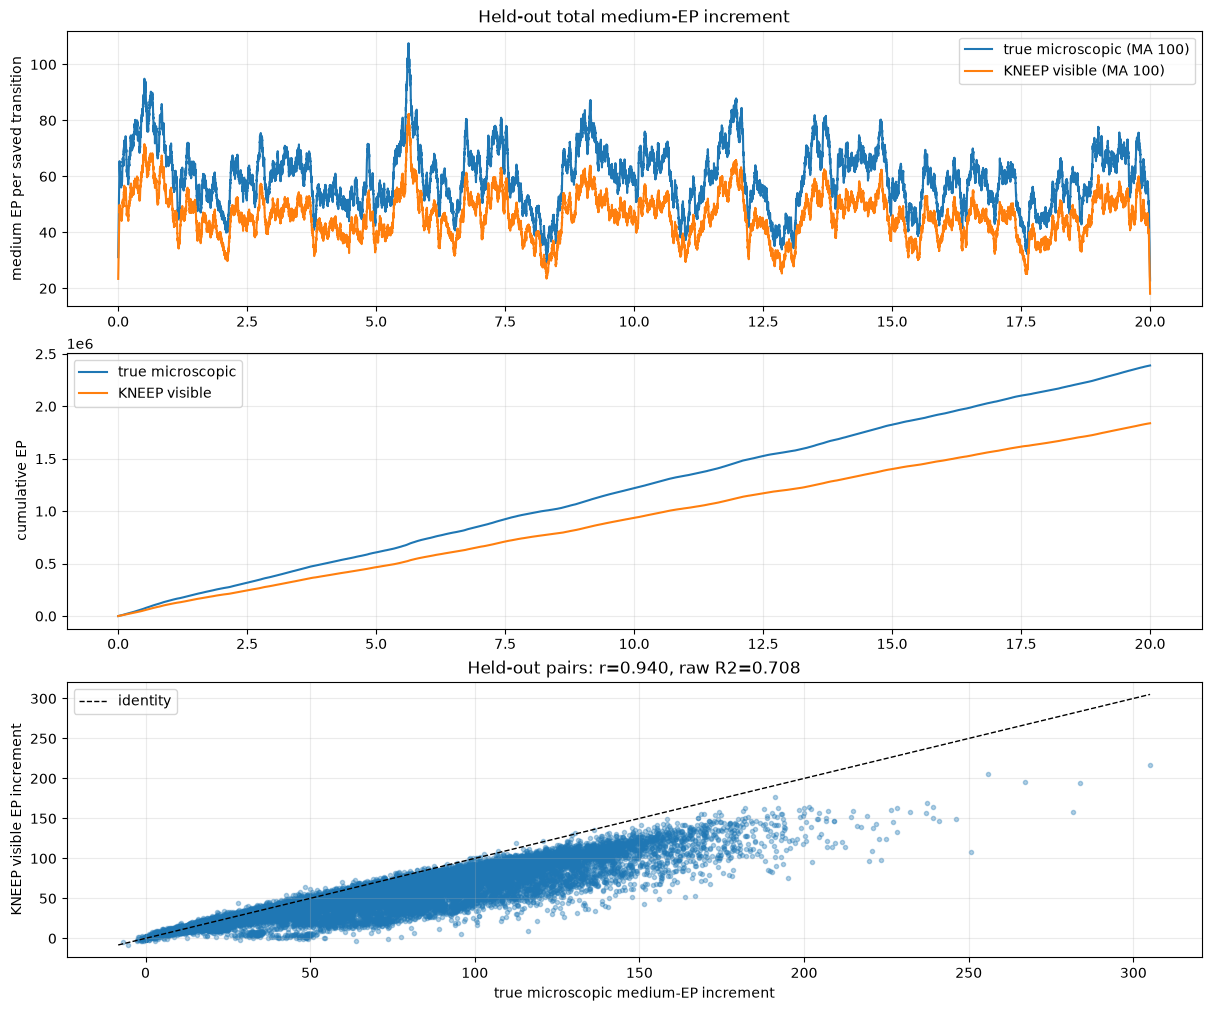

In [75]:
def moving_average(values, window):
    values = np.asarray(values)
    if len(values) == 0:
        return values
    window = max(1, min(int(window), len(values)))
    return np.convolve(values, np.ones(window) / window, mode="same")


n_pairs_per_test_replica = test_video.shape[1] - 1
time_mid = test_result["times"][:-1].numpy() + 0.5 * dt_saved
time_end = test_result["times"][1:].numpy()
plot_slice = slice(0, n_pairs_per_test_replica)  # first held-out replica
smooth_window = min(100, max(1, n_pairs_per_test_replica // 10))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
axes[0].plot(
    time_mid,
    moving_average(gt_total_ep[plot_slice], smooth_window),
    label=f"true microscopic (MA {smooth_window})",
)
axes[0].plot(
    time_mid,
    moving_average(pred_total_ep[plot_slice], smooth_window),
    label=f"KNEEP visible (MA {smooth_window})",
)
axes[0].set_ylabel("medium EP per saved transition")
axes[0].set_title("Held-out total medium-EP increment")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(time_end, np.cumsum(gt_total_inc.numpy()[plot_slice]), label="true microscopic")
axes[1].plot(time_end, np.cumsum(pred_total_inc.numpy()[plot_slice]), label="KNEEP visible")
axes[1].set_ylabel("cumulative EP")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].scatter(gt_total_ep, pred_total_ep, s=9, alpha=0.35)
lo = float(min(gt_total_ep.min(), pred_total_ep.min()))
hi = float(max(gt_total_ep.max(), pred_total_ep.max()))
axes[2].plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")
axes[2].set_xlabel("true microscopic medium-EP increment")
axes[2].set_ylabel("KNEEP visible EP increment")
axes[2].set_title(
    f"Held-out pairs: r={total_metrics['pearson_r']:.3f}, "
    f"raw R2={total_metrics['raw_r2']:.3f}"
)
axes[2].legend()
axes[2].grid(alpha=0.25)

fig.savefig(current_result_folder / "total_medium_ep_comparison.png", dpi=160)
plt.show()

## 7. True versus learned local medium EP

The true map uses the simulator's **departure-site gauge**.  The learned map is
localized by the convolution center and may choose a different gauge while
preserving a similar total.  Therefore the notebook shows a single interval,
the held-out time average, residuals, and pixelwise metrics; the total and
cumulative comparisons above remain the gauge-robust diagnostics.  Pixel R2 is
only a gauge-dependent localization diagnostic, and the absolute time-mean map
can also reflect pinning or drift of the periodic MIPS cluster.

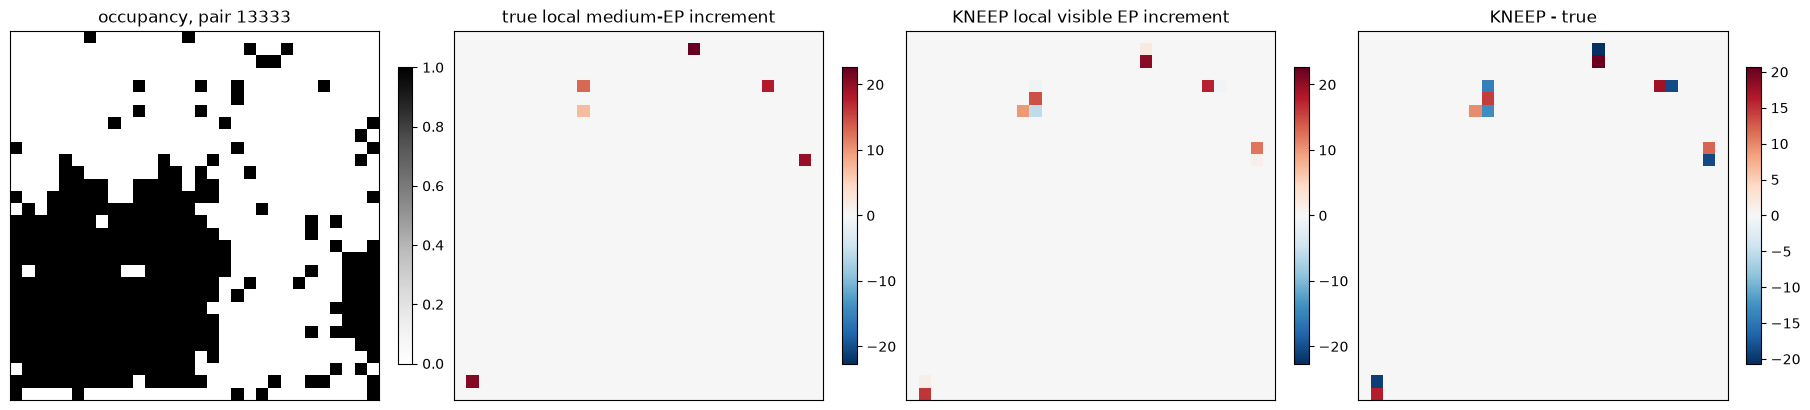

single-pair pixel metrics:
{
  "count": 900,
  "target_mean": 0.11243531545003255,
  "prediction_mean": 0.09621146585211085,
  "mean_ratio": 0.8557050377545146,
  "mae": 0.22148785816202438,
  "rmse": 1.910880649171911,
  "pearson_r": 0.011750699418258275,
  "raw_r2": -0.763316199113919
}


In [76]:
sample_index = n_pairs_per_test_replica // 3
test_replica_original = int(test_ensemble_ids[0])
occupancy_sample = test_result["occupancy"][sample_index, test_replica_original].numpy()
true_sample = gt_local_ep[sample_index]
pred_sample = pred_local_ep[sample_index]
residual_sample = pred_sample - true_sample

vmax = max(float(np.abs(true_sample).max()), float(np.abs(pred_sample).max()), 1.0e-12)
residual_vmax = max(float(np.abs(residual_sample).max()), 1.0e-12)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)
im0 = axes[0].imshow(occupancy_sample.T, origin="lower", cmap="Greys", vmin=0, vmax=1)
axes[0].set_title(f"occupancy, pair {sample_index}")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(true_sample.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("true local medium-EP increment")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(pred_sample.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title("KNEEP local visible EP increment")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

im3 = axes[3].imshow(
    residual_sample.T,
    origin="lower",
    cmap="RdBu_r",
    vmin=-residual_vmax,
    vmax=residual_vmax,
)
axes[3].set_title("KNEEP - true")
fig.colorbar(im3, ax=axes[3], shrink=0.8)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.savefig(current_result_folder / "local_medium_ep_single_pair.png", dpi=170)
plt.show()

single_local_metrics = comparison_metrics(true_sample.ravel(), pred_sample.ravel())
print("single-pair pixel metrics:")
print(json.dumps(single_local_metrics, indent=2))

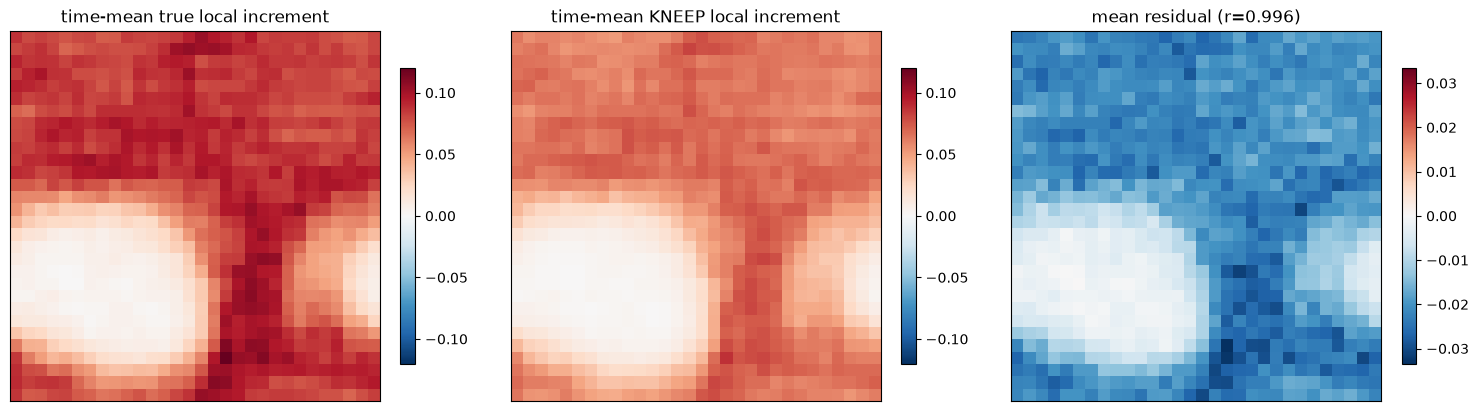

time-mean pixel metrics:
{
  "count": 900,
  "target_mean": 0.06636013048516665,
  "prediction_mean": 0.04892644455215001,
  "mean_ratio": 0.7372867442309573,
  "mae": 0.017434023385463255,
  "rmse": 0.019095291561631478,
  "pearson_r": 0.9963894173697181,
  "raw_r2": 0.6366325624231968
}


In [71]:
true_mean_map = gt_local_ep[:n_pairs_per_test_replica].mean(axis=0)
pred_mean_map = pred_local_ep[:n_pairs_per_test_replica].mean(axis=0)
mean_residual = pred_mean_map - true_mean_map
mean_local_metrics = comparison_metrics(true_mean_map.ravel(), pred_mean_map.ravel())

# The printed pixel means and plotted fields must refer to exactly the same
# arrays.  In particular, a true-map mean above a plot's colour limit signals
# clipping (or that an old notebook cell was run), not a simulator scale error.
np.testing.assert_allclose(true_mean_map.mean(), gt_local_ep.mean(), rtol=2.0e-6, atol=2.0e-6)
np.testing.assert_allclose(pred_mean_map.mean(), pred_local_ep.mean(), rtol=2.0e-6, atol=2.0e-6)

vmax = max(float(np.abs(true_mean_map).max()), float(np.abs(pred_mean_map).max()), 1.0e-12)
residual_vmax = max(float(np.abs(mean_residual).max()), 1.0e-12)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
im0 = axes[0].imshow(true_mean_map.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_title("time-mean true local increment")
fig.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].imshow(pred_mean_map.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("time-mean KNEEP local increment")
fig.colorbar(im1, ax=axes[1], shrink=0.8)
im2 = axes[2].imshow(
    mean_residual.T,
    origin="lower",
    cmap="RdBu_r",
    vmin=-residual_vmax,
    vmax=residual_vmax,
)
axes[2].set_title(
    f"mean residual (r={mean_local_metrics['pearson_r']:.3f})"
)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.savefig(current_result_folder / "local_medium_ep_time_mean.png", dpi=170)
plt.show()

print("time-mean pixel metrics:")
print(json.dumps(mean_local_metrics, indent=2))

## 8. K-shell contribution spectrum and saved diagnostics

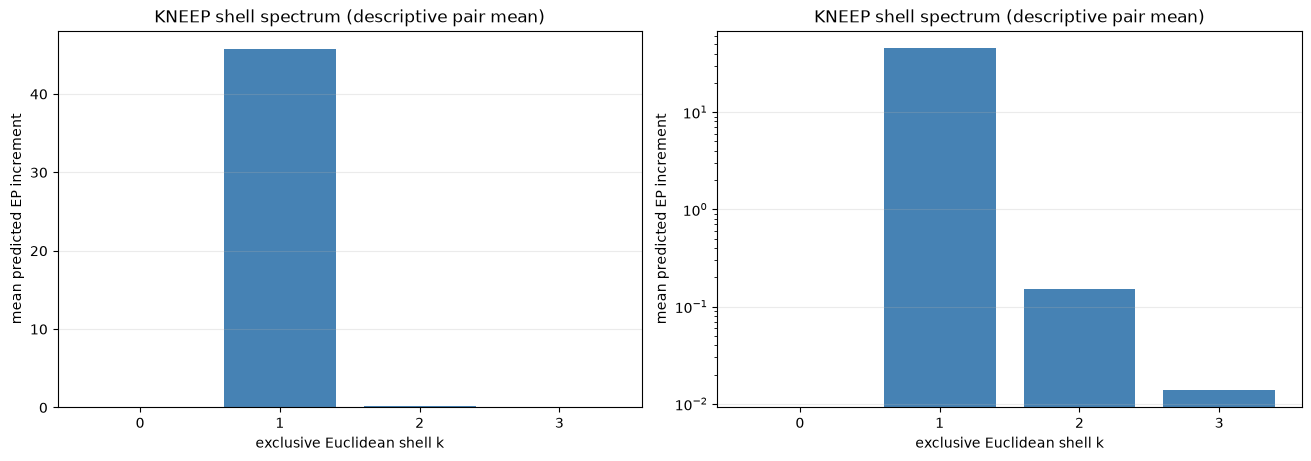

{
  "model": "MultiScaleK_2DF",
  "observation_mode": "occupancy_polarization",
  "physics": {
    "N": 344,
    "L": 15.0,
    "grid_size": 30,
    "sigma": 0.5,
    "epsilon": 1.0,
    "mobility": 1.0,
    "v0": 50.0,
    "Dr": 1.5,
    "Dt": 1.0,
    "dt": 0.0001,
    "prefactor": "cv",
    "strict_probabilities": true,
    "probability_tolerance": 1e-06,
    "shuffle_particles": true,
    "seed": 7,
    "device": "cuda:0",
    "dtype": "float32",
    "update_scheme": "five_color",
    "backend": "torch",
    "actual_phi": 0.30019663134302466,
    "dl": 0.5,
    "Pe": 66.66666666666667
  },
  "trajectory_config": {
    "train_validation": {
      "cache_version": 2,
      "sampler_source_sha256": "164305f9eb5f029fac99c8cd6e00e7055293e6b387aa1f67e3a706bebc3f16ef",
      "physics": {
        "N": 344,
        "L": 15.0,
        "grid_size": 30,
        "sigma": 0.5,
        "epsilon": 1.0,
        "mobility": 1.0,
        "v0": 50.0,
        "Dr": 1.5,
        "Dt": 1.0,
        "dt":

In [78]:
# Branch totals are raw-map spatial means; /G^2 is only for local maps.
branch_total_ep = raw_pred_branch_maps.mean(dim=(-2, -1)).numpy()
np.testing.assert_allclose(branch_total_ep.sum(axis=1), pred_total_ep, rtol=2.0e-5, atol=2.0e-4)
mean_branch_ep = branch_total_ep.mean(axis=0)
distances = np.arange(0 if opt.include_k0 else 1, opt.max_distance + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].bar(distances, mean_branch_ep, color="steelblue")
axes[0].set_xlabel("exclusive Euclidean shell k")
axes[0].set_ylabel("mean predicted EP increment")
axes[0].set_title("KNEEP shell spectrum (descriptive pair mean)")
axes[0].set_xticks(distances)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(distances, mean_branch_ep, color="steelblue")
axes[1].set_xlabel("exclusive Euclidean shell k")
axes[1].set_ylabel("mean predicted EP increment")
axes[1].set_title("KNEEP shell spectrum (descriptive pair mean)")
axes[1].set_xticks(distances)
axes[1].set_yscale("log")
axes[1].grid(axis="y", alpha=0.25)

fig.savefig(current_result_folder / "kneep_shell_spectrum.png", dpi=160)
plt.show()

summary = {
    "model": opt.model_type,
    "observation_mode": OBSERVATION_MODE,
    "physics": {**physics, "actual_phi": params.phi, "dl": params.dl, "Pe": params.Pe},
    "trajectory_config": trajectory_config,
    "trajectory_cache_id": {"train_validation": train_val_cache_id, "test": test_cache_id},
    "sampler_source_sha256": sampler_source_sha256,
    "split": {
        "train_ensemble_ids": train_ensemble_ids.tolist(),
        "validation_ensemble_ids": val_ensemble_ids.tolist(),
        "test_ensemble_ids": test_ensemble_ids.tolist(),
        "pairs_per_ensemble": int(n_pairs_per_test_replica),
    },
    "best_iteration": int(checkpoint["iteration"]),
    "best_validation_loss": float(checkpoint["val_loss"]),
    "held_out_objective": float(test_objective),
    "dt_saved": float(dt_saved),
    "scale_audit": scale_audit,
    "stationarity_diagnostics": stationarity,
    "total_increment_metrics": total_metrics,
    "single_pair_local_metrics": single_local_metrics,
    "time_mean_local_metrics": mean_local_metrics,
    "local_metric_note": "Gauge-dependent diagnostic; not a pairwise thermodynamic equality or bound.",
    "mean_branch_increment": mean_branch_ep.tolist(),
    "mean_true_total_increment": float(gt_total_ep.mean()),
    "mean_predicted_total_increment": float(pred_total_ep.mean()),
    "mean_true_active_medium_ep_increment": float(test_result["exact_active_medium_ep"].mean()),
    "mean_true_wca_medium_ep_increment": float(test_result["exact_wca_medium_ep"].mean()),
    "mean_accepted_hops_per_saved_interval": float(
        test_result["accepted_hops"].float().mean()
    ),
}


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


summary_for_json = json_safe(summary)
(current_result_folder / "summary.json").write_text(
    json.dumps(summary_for_json, indent=2, allow_nan=False), encoding="utf-8"
)
np.savez_compressed(
    current_result_folder / "held_out_ep_comparison.npz",
    test_ensemble_ids=test_ensemble_ids.numpy(),
    times_mid=time_mid,
    times_end=time_end,
    gt_total_increment=gt_total_inc.numpy(),
    pred_total_increment=pred_total_inc.numpy(),
    gt_local_increment=gt_local_ep,
    pred_local_increment=pred_local_ep,
    gt_time_mean_local_increment=true_mean_map,
    pred_time_mean_local_increment=pred_mean_map,
    mean_branch_increment=mean_branch_ep,
    history_iteration=np.asarray(history_iter),
    history_train_loss=np.asarray(history_train),
    history_validation_loss=np.asarray(history_val),
)

print(json.dumps(summary_for_json, indent=2, allow_nan=False))
print("saved diagnostics under:", current_result_folder)